# 🚀 LightGBM Model for Exam Score Prediction

This notebook trains a LightGBM regression model to predict student exam scores (0-100).

## Table of Contents
1. [Setup & Load Data](#1-setup--load-data)
2. [Model Training](#2-model-training)
3. [Model Evaluation](#3-model-evaluation)
4. [Feature Importance](#4-feature-importance)
5. [Generate Predictions & Submit](#5-generate-predictions--submit)

## 1. Setup & Load Data

In [13]:
# Import libraries
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Paths
DATA_DIR = Path('../data/processed')
SUBMISSION_DIR = Path('../submissions')
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [14]:
# Load processed data
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
test_ids = np.load(DATA_DIR / 'test_ids.npy')

# Load train/val split
X_tr = np.load(DATA_DIR / 'X_tr.npy')
X_val = np.load(DATA_DIR / 'X_val.npy')
y_tr = np.load(DATA_DIR / 'y_tr.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')

# Load feature names
feature_names = pd.read_csv(DATA_DIR / 'feature_names.csv').iloc[:, 0].tolist()

print("Data loaded successfully!")
print(f"\nTraining set: {X_train.shape}")
print(f"  - Train split: {X_tr.shape}")
print(f"  - Validation split: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nNumber of features: {len(feature_names)}")

Data loaded successfully!

Training set: (630000, 27)
  - Train split: (504000, 27)
  - Validation split: (126000, 27)
Test set: (270000, 27)

Number of features: 27


## 2. Model Training

In [15]:
# Create LightGBM datasets
train_data = lgb.Dataset(X_tr, label=y_tr, feature_name=feature_names)
val_data = lgb.Dataset(X_val, label=y_val, feature_name=feature_names, reference=train_data)

print("✅ LightGBM datasets created")

✅ LightGBM datasets created


In [16]:
# LightGBM hyperparameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'seed': 42
}

print("Model parameters:")
for k, v in params.items():
    print(f"  {k}: {v}")

Model parameters:
  objective: regression
  metric: rmse
  boosting_type: gbdt
  learning_rate: 0.05
  num_leaves: 31
  max_depth: -1
  min_child_samples: 20
  feature_fraction: 0.8
  bagging_fraction: 0.8
  bagging_freq: 5
  reg_alpha: 0.1
  reg_lambda: 0.1
  verbose: -1
  seed: 42


In [17]:
# Train the model
print("Training LightGBM model...")
print("=" * 50)

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print("=" * 50)
print(f"✅ Training complete! Best iteration: {model.best_iteration}")

Training LightGBM model...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 8.82916	valid's rmse: 8.83558
[200]	train's rmse: 8.77122	valid's rmse: 8.79174
[300]	train's rmse: 8.74513	valid's rmse: 8.78007
[400]	train's rmse: 8.72374	valid's rmse: 8.7732
[500]	train's rmse: 8.70438	valid's rmse: 8.76802
[600]	train's rmse: 8.68708	valid's rmse: 8.76462
[700]	train's rmse: 8.66992	valid's rmse: 8.76153
[800]	train's rmse: 8.6531	valid's rmse: 8.75853
[900]	train's rmse: 8.63779	valid's rmse: 8.75724
[1000]	train's rmse: 8.62293	valid's rmse: 8.75539
Did not meet early stopping. Best iteration is:
[1000]	train's rmse: 8.62293	valid's rmse: 8.75539
✅ Training complete! Best iteration: 1000


## 3. Model Evaluation

In [18]:
# Make predictions on validation set
y_val_pred = model.predict(X_val, num_iteration=model.best_iteration)

# Clip predictions to 0-100 range
y_val_pred = np.clip(y_val_pred, 0, 100)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("=" * 50)
print("VALIDATION SET METRICS")
print("=" * 50)
print(f"RMSE:  {rmse:.4f}")
print(f"MAE:   {mae:.4f}")
print(f"R²:    {r2:.4f}")
print("=" * 50)

VALIDATION SET METRICS
RMSE:  8.7552
MAE:   6.9792
R²:    0.7845


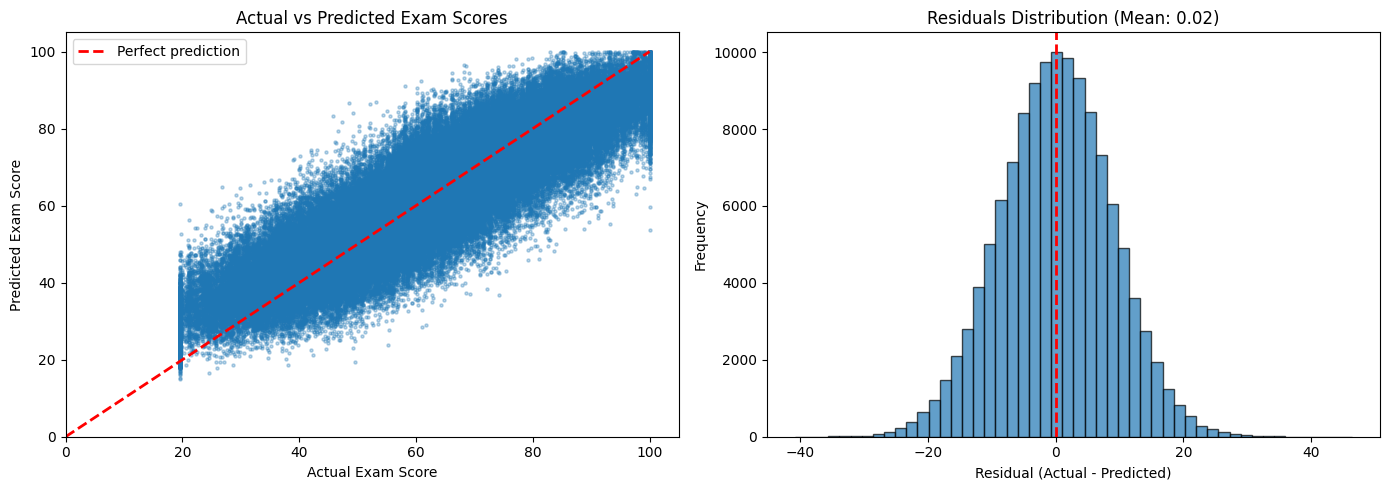

In [19]:
# Plot actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_val, y_val_pred, alpha=0.3, s=5)
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Exam Score')
axes[0].set_ylabel('Predicted Exam Score')
axes[0].set_title('Actual vs Predicted Exam Scores')
axes[0].legend()
axes[0].set_xlim(0, 105)
axes[0].set_ylim(0, 105)

# Residuals distribution
residuals = y_val - y_val_pred
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residuals Distribution (Mean: {residuals.mean():.2f})')

plt.tight_layout()
plt.show()

## 4. Feature Importance

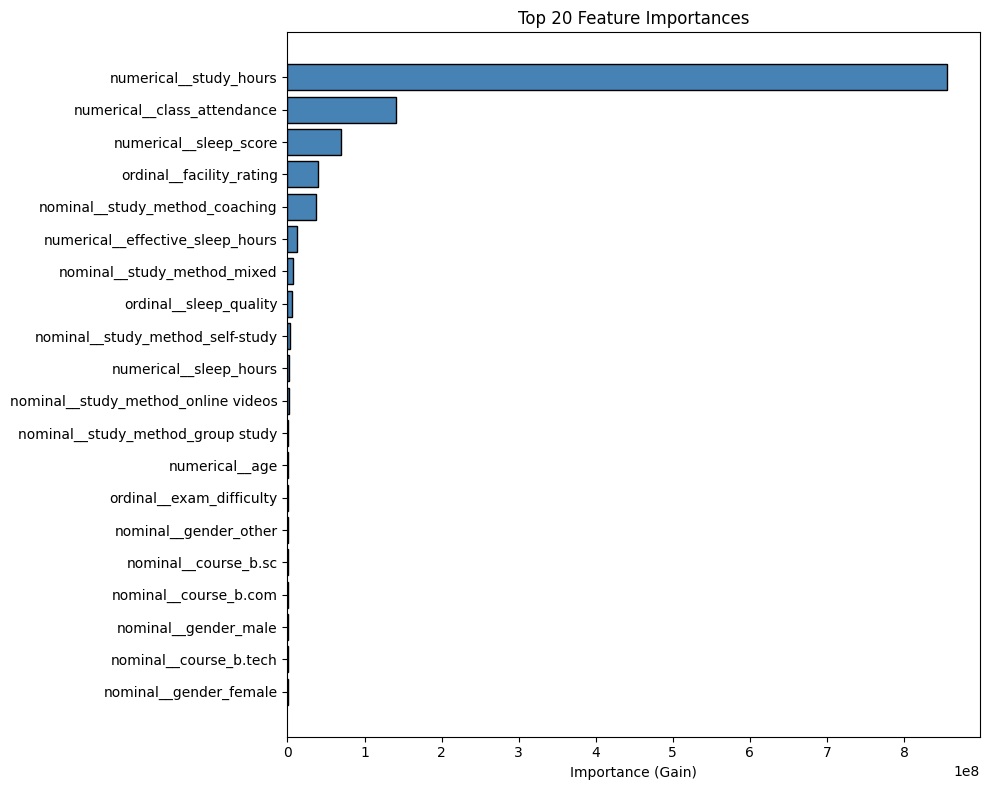


Top 15 Most Important Features:
                            feature   importance
             numerical__study_hours 8.559021e+08
        numerical__class_attendance 1.403804e+08
             numerical__sleep_score 6.901321e+07
           ordinal__facility_rating 3.906421e+07
     nominal__study_method_coaching 3.661839e+07
   numerical__effective_sleep_hours 1.258436e+07
        nominal__study_method_mixed 7.043377e+06
             ordinal__sleep_quality 5.933487e+06
   nominal__study_method_self-study 3.885540e+06
             numerical__sleep_hours 1.949955e+06
nominal__study_method_online videos 1.929449e+06
  nominal__study_method_group study 9.585471e+05
                     numerical__age 8.709918e+05
           ordinal__exam_difficulty 2.951442e+05
              nominal__gender_other 2.047358e+05


In [ ]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(importance_df))
top_features = importance_df.head(top_n)

ax.barh(range(top_n), top_features['importance'].values, color='steelblue', edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)')
ax.set_title(f'Top {top_n} Feature Importances')
plt.tight_layout()
plt.show()

print("\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

## 5. Generate Predictions & Submit

In [21]:
# Retrain on full training data for final submission
print("Retraining on full training data...")

full_train_data = lgb.Dataset(X_train, label=y_train, feature_name=feature_names)

final_model = lgb.train(
    params,
    full_train_data,
    num_boost_round=model.best_iteration  # Use best iteration from CV
)

print(f"✅ Final model trained with {model.best_iteration} iterations")

Retraining on full training data...
✅ Final model trained with 1000 iterations


In [22]:
# Generate predictions on test set
test_predictions = final_model.predict(X_test)

# Clip predictions to valid range (0-100)
test_predictions = np.clip(test_predictions, 0, 100)

print(f"Test predictions generated: {len(test_predictions):,} samples")
print(f"\nPrediction statistics:")
print(f"  Min: {test_predictions.min():.2f}")
print(f"  Max: {test_predictions.max():.2f}")
print(f"  Mean: {test_predictions.mean():.2f}")
print(f"  Std: {test_predictions.std():.2f}")

Test predictions generated: 270,000 samples

Prediction statistics:
  Min: 14.50
  Max: 100.00
  Mean: 62.52
  Std: 16.75


In [23]:
# Create submission DataFrame
submission = pd.DataFrame({
    'id': test_ids,
    'exam_score': test_predictions
})

# Verify submission format
print("Submission DataFrame:")
print(submission.head(10))
print(f"\nShape: {submission.shape}")

Submission DataFrame:
       id  exam_score
0  630000   72.339621
1  630001   69.888693
2  630002   88.765957
3  630003   55.530578
4  630004   47.617939
5  630005   71.527819
6  630006   73.829519
7  630007   58.610173
8  630008   77.870771
9  630009   89.503653

Shape: (270000, 2)


In [24]:
# Save submission CSV
submission_path = SUBMISSION_DIR / 'lightgbm_submission.csv'
submission.to_csv(submission_path, index=False)

print(f"✅ Submission saved to: {submission_path}")
print(f"\nFile size: {submission_path.stat().st_size / 1024:.2f} KB")

# Verify the saved file
print("\nFirst few lines of saved submission:")
print(pd.read_csv(submission_path).head())

✅ Submission saved to: ../submissions/lightgbm_submission.csv

File size: 6600.32 KB

First few lines of saved submission:
       id  exam_score
0  630000   72.339621
1  630001   69.888693
2  630002   88.765957
3  630003   55.530578
4  630004   47.617939


## Summary

**Model:** LightGBM Regressor
- Objective: Regression (RMSE)
- Early stopping with 50 rounds patience
- Predictions clipped to valid range [0, 100]

**Output:** `submissions/lightgbm_submission.csv`
- Format: `id, exam_score`
- Ready for Kaggle submission

**Next Steps:**
- Hyperparameter tuning with Optuna
- Cross-validation for more robust evaluation
- Ensemble with other models (XGBoost, CatBoost)
- Additional feature engineering